# Diagnostic: log(I/f) vs log(f)  —  Sigma Profiled

**왼쪽**: `log(I / f_profiled)` vs `log(f_profiled)`  
→ ratio가 expected level에 따라 체계적 trend 있는지 확인 (수평이면 shape OK)

**오른쪽**: `log(f_profiled)` vs `log(||ω||)`  
→ 모델이 예측하는 고주파 decay shape 확인

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────
import sys
gems_tco_path = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
import os
import cmath
sys.path.append(gems_tco_path)

from pathlib import Path

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import GEMS_TCO
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO import debiased_whittle_2110 as debiased_whittle

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cpu


In [3]:
# ── Configuration & Data loading ──────────────────────────────────────────
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]
MONTH     = 7
YEARS     = ['2022', '2023', '2024', '2025']
MM_COND   = 8

data_load_instance = load_data_dynamic_processed(config.mac_data_load_path)

tensors_dw_by_year = {}
maps_dw_by_year    = {}

for year in YEARS:
    df_map, ord_mm, nns_map, monthly_mean = data_load_instance.load_maxmin_ordered_data_bymonthyear(
        lat_lon_resolution=[1, 1],
        mm_cond_number=MM_COND,
        years_=[year],
        months_=[MONTH],
        lat_range=LAT_RANGE,
        lon_range=LON_RANGE,
        is_whittle=False
    )
    daily_tensors, daily_maps = [], []
    for day_index in range(28):
        hour_indices = [day_index * 8, (day_index + 1) * 8]
        day_map, day_tensor = data_load_instance.load_working_data(
            df_map, monthly_mean, hour_indices,
            ord_mm=None, dtype=torch.float64, keep_ori=False
        )
        daily_tensors.append(day_tensor)
        daily_maps.append(day_map)

    tensors_dw_by_year[year] = daily_tensors
    maps_dw_by_year[year]    = daily_maps
    print(f"  {year}: {len(daily_tensors)} days loaded,  shape={daily_tensors[0].shape}")

--- Global Monthly Mean for 2022-7: 250.6500 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  2022: 28 days loaded,  shape=torch.Size([145008, 11])
--- Global Monthly Mean for 2023-7: 249.7131 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  2023: 28 days loaded,  shape=torch.Size([145008, 11])
--- Global Monthly Mean for 2024-7: 257.9726 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  2024: 28 days loaded,  shape=torch.Size([145008, 11])
--- Global Monthly Mean for 2025-7: 241.4412 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  2025: 28 days loaded,  shape=torch.Size([145008, 11])


In [4]:
# ── Estimates loading ──────────────────────────────────────────────────────
V_GRID_LON = -0.0048
PARAM_COLS = ['sigma_sq', 'range_lat', 'range_lon', 'range_time',
              'advec_lat', 'advec_lon', 'nugget']

EST_PATH   = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/july_22_23_24_25/")
dw_raw     = pd.read_csv(EST_PATH / "real_dw_july_22_23_24_25.csv")
vecc_raw   = pd.read_csv(EST_PATH / "real_vecc_july_22_23_24_25_mm20.csv")
cauchy_raw = pd.read_csv(EST_PATH / "real_cauchy_b10_july_22_23_24_25_mm20.csv")

_RAW_PARAM_COLS = ['sigma', 'range_lat', 'range_lon', 'range_time',
                   'advec_lat', 'advec_lon', 'nugget']

def split_estimates_by_year(df, years=YEARS, n_days=28):
    df = df.copy()
    df['_year']    = df['day'].astype(str).str[:4]
    df['_day_num'] = df['day'].astype(str).str.extract(r'-(\d+)$')[0].astype(int)
    result = {}
    for yr in years:
        sub = (df[df['_year'] == yr]
               .set_index('_day_num')[_RAW_PARAM_COLS]
               .reindex(range(1, n_days + 1)))
        sub.columns = PARAM_COLS
        result[yr] = sub.reset_index(drop=True)
    return result

dw_by_year     = split_estimates_by_year(dw_raw)
vecc_by_year   = split_estimates_by_year(vecc_raw)
cauchy_by_year = split_estimates_by_year(cauchy_raw)

for yr in YEARS:
    dw_by_year[yr]['advec_lon'] = dw_by_year[yr]['advec_lon'] + V_GRID_LON

for yr in YEARS:
    print(f"  {yr}  DW={len(dw_by_year[yr])}  Vecc={len(vecc_by_year[yr])}  Cauchy={len(cauchy_by_year[yr])}")

  2022  DW=28  Vecc=28  Cauchy=28
  2023  DW=28  Vecc=28  Cauchy=28
  2024  DW=28  Vecc=28  Cauchy=28
  2025  DW=28  Vecc=28  Cauchy=28


## Core: spectral components 추출 (sigma profiled)

In [5]:
def compute_spectral_components(data_tensor, params_row, device):
    """
    각 (주파수, 시간슬라이스) 포인트에 대해 sigma profiled 결과 반환.

      I_obs[i,j,k]  = |J[i,j,k]|^2            (empirical diagonal)
      f_exp[i,j,k]  = I_expected[i,j,k,k].real (expected diagonal)
      scaling       = mean(whitened_power)       (sigma profiling factor)

    Returns
    -------
    freq_norm_exp  : (n1*n2*p,)  ||omega||
    log_ratio_prof : log(I_obs / f_profiled)   ← y축 (왼쪽 플롯)
    log_f_prof     : log(f_profiled)           ← x축 (왼쪽) / y축 (오른쪽)
    sigma_sq       : 입력 sigma^2
    sigma_profiled : profiled sigma^2
    """
    dwl = debiased_whittle.debiased_whittle_likelihood()

    DELTA_LAT = 0.044
    DELTA_LON = 0.063
    LAT_COL, LON_COL, VAL_COL, TIME_COL = 0, 1, 2, 3

    # 1. Parameter extraction
    try:
        sigma_sq = params_row['sigma_sq']
    except KeyError:
        sigma_sq = params_row['sigma']
    range_lat   = params_row['range_lat']
    range_lon   = params_row['range_lon']
    range_time  = params_row['range_time']
    advec_lat   = params_row['advec_lat']
    advec_lon   = params_row['advec_lon']
    nugget      = params_row['nugget']
    nugget_safe = nugget if nugget > 1e-9 else 1e-15

    phi2 = 1.0 / range_lon
    phi1 = sigma_sq * phi2
    phi3 = (range_lon / range_lat) ** 2
    phi4 = (range_lon / range_time) ** 2

    params_tensor = torch.tensor([
        np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
        advec_lat, advec_lon, np.log(nugget_safe)
    ], device=device, dtype=torch.float64)

    # 2. Time slices
    unique_times = torch.unique(data_tensor[:, TIME_COL])
    time_slices  = [data_tensor[data_tensor[:, TIME_COL] == t] for t in unique_times]

    # 3. J-vector + taper autocorrelation
    J_vec, n1, n2, p_time, taper_grid, obs_masks = dwl.generate_Jvector_tapered_mv(
        time_slices, tapering_func=dwl.cgn_hamming,
        lat_col=LAT_COL, lon_col=LON_COL, val_col=VAL_COL, device=device
    )
    taper_autocorr = dwl.calculate_taper_autocorrelation_multivariate(
        taper_grid, obs_masks, n1, n2, device
    )
    del obs_masks

    # 4. Expected periodogram: (n1, n2, p, p)
    with torch.no_grad():
        I_expected = dwl.expected_periodogram_fft_tapered(
            params_tensor, n1, n2, p_time, taper_autocorr, DELTA_LAT, DELTA_LON
        )

    # 5. Cholesky whitening → scaling factor
    eye = torch.eye(p_time, device=device, dtype=torch.complex128)
    try:
        L = torch.linalg.cholesky(I_expected + eye * 1e-9)
    except RuntimeError:
        L = torch.linalg.cholesky(I_expected + eye * 1e-6)

    Z_white       = torch.linalg.solve_triangular(L, J_vec.unsqueeze(-1), upper=False)
    whitened_power = (Z_white.abs() ** 2).squeeze(-1).cpu().numpy()  # (n1, n2, p)
    scaling_factor = float(np.nanmean(
        np.fft.fftshift(whitened_power, axes=(0, 1)).flatten()
    ))
    sigma_profiled = sigma_sq * scaling_factor

    # 6. I_obs & f_exp diagonal (original space)
    I_obs_np = (J_vec.abs() ** 2).cpu().numpy()                        # (n1, n2, p)
    f_exp_np  = I_expected.diagonal(dim1=2, dim2=3).real.cpu().numpy() # (n1, n2, p)
    f_exp_np  = np.maximum(np.abs(f_exp_np), 1e-30)

    I_obs_flat = np.fft.fftshift(I_obs_np, axes=(0, 1)).flatten()
    f_exp_flat = np.fft.fftshift(f_exp_np, axes=(0, 1)).flatten()

    # 7. Profiled: f_profiled = f_exp * scaling_factor
    log_scale      = np.log(scaling_factor)
    log_ratio_prof = np.log(np.maximum(I_obs_flat, 1e-30)) - np.log(f_exp_flat) - log_scale
    log_f_prof     = np.log(f_exp_flat) + log_scale

    # 8. Frequency norm
    freq_lat      = np.fft.fftshift(np.fft.fftfreq(n1, d=DELTA_LAT))
    freq_lon      = np.fft.fftshift(np.fft.fftfreq(n2, d=DELTA_LON))
    g_lat, g_lon  = np.meshgrid(freq_lat, freq_lon, indexing='ij')
    freq_norm     = np.sqrt(g_lat**2 + g_lon**2).flatten()
    freq_norm_exp = np.repeat(freq_norm, p_time)

    return freq_norm_exp, log_ratio_prof, log_f_prof, sigma_sq, sigma_profiled

## Plotting

In [6]:
def _binned_trend(x, y, n_bins=35, smooth_sigma=1.5):
    valid = np.isfinite(x) & np.isfinite(y)
    xv, yv = x[valid], y[valid]
    if len(xv) < 20:
        return [], []
    edges = np.percentile(xv, np.linspace(0, 100, n_bins + 1))
    bx, by = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (xv >= lo) & (xv < hi)
        if m.sum() > 5:
            bx.append(np.median(xv[m]))
            by.append(np.median(yv[m]))
    if len(by) > 3:
        by = list(gaussian_filter1d(by, sigma=smooth_sigma))
    return bx, by


def plot_logIf_vs_logf(day_idx, dw_df, raw_tensors, raw_maps,
                        year_label='', n_scatter=6000):
    """
    Two-panel diagnostic (sigma profiled).

    Left  — log(I / f_profiled) vs log(f_profiled)
             수평 trend → 모델 spectral shape OK
             기울어지면 → 고주파 or 저주파 misfit

    Right — log(f_profiled) vs log(||ω||)
             모델의 spectral decay shape
    """
    a_dummy   = [13.357, 0.1441, 0.1855, 1.1652, 0.0197, -0.1576, 0]
    lat_range = [-3, 2]
    lon_range = [121, 131]

    print(f"[Day {day_idx}] preprocessing...")
    db = debiased_whittle.debiased_whittle_preprocess(
        raw_tensors, raw_maps, day_idx=day_idx,
        params_list=a_dummy, lat_range=lat_range, lon_range=lon_range
    )
    subsetted   = db.generate_spatially_filtered_days(*lat_range, *lon_range)
    data_tensor = (torch.from_numpy(subsetted) if isinstance(subsetted, np.ndarray)
                   else subsetted).to(DEVICE)

    if data_tensor.shape[0] == 0:
        print("Empty tensor — skipping.")
        return

    print(f"[Day {day_idx}] computing spectral components...")
    freq_norm, log_ratio, log_f, sig_in, sig_prof = \
        compute_spectral_components(data_tensor, dw_df.iloc[day_idx], DEVICE)

    print(f"  sigma_input={sig_in:.3f}  sigma_profiled={sig_prof:.3f}")

    rng = np.random.default_rng(42)
    n_pts = len(log_f)
    idx   = rng.choice(n_pts, min(n_scatter, n_pts), replace=False)

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f"[{year_label} Day {day_idx}]  log(I/f) vs log(f)  —  σ²={sig_in:.3f} → profiled σ²={sig_prof:.3f}",
        fontsize=14, fontweight='bold'
    )

    # ── Left: log(I/f_profiled) vs log(f_profiled) ────────────────────────
    ax_l.scatter(log_f[idx], log_ratio[idx], alpha=0.2, s=4, color='steelblue')

    bx, by = _binned_trend(log_f, log_ratio)
    if bx:
        ax_l.plot(bx, by, color='navy', linewidth=2.5, label='Binned median trend')

    ax_l.axhline(0, color='black', linestyle='--', linewidth=1.3, alpha=0.7, label='ratio = 1')
    ax_l.set_xlabel('log(f_profiled)', fontsize=13)
    ax_l.set_ylabel('log(I / f_profiled)', fontsize=13)
    ax_l.set_title('Ratio vs Expected Level\n(수평 → shape 정확, 기울어지면 misfit)', fontsize=12)
    ax_l.legend(fontsize=11, markerscale=3)
    ax_l.grid(True, alpha=0.3)

    # ── Right: log(f_profiled) vs log(||ω||) ──────────────────────────────
    log_omega   = np.log(np.maximum(freq_norm, 1e-10))
    valid_omega = (freq_norm > 0)

    ax_r.scatter(log_omega[idx], log_f[idx], alpha=0.15, s=4, color='darkorange')

    bx_r, by_r = _binned_trend(log_omega[valid_omega], log_f[valid_omega])
    if bx_r:
        ax_r.plot(bx_r, by_r, color='darkorange', linewidth=2.5, label='Model spectral shape')

    ax_r.set_xlabel('log(||ω||)', fontsize=13)
    ax_r.set_ylabel('log(f_profiled)', fontsize=13)
    ax_r.set_title('Model Spectral Shape\n(slope = spectral decay rate)', fontsize=12)
    ax_r.legend(fontsize=11, markerscale=3)
    ax_r.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Run — single day

[Day 2] preprocessing...
[Day 2] computing spectral components...
  sigma_input=7.391  sigma_profiled=7.422


/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_2433/1320848817.py:93: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_2433/1320848817.py:93: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_2433/1320848817.py:93: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_2433/1320848817.py:93: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_2433/1320848817.py:93: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykern

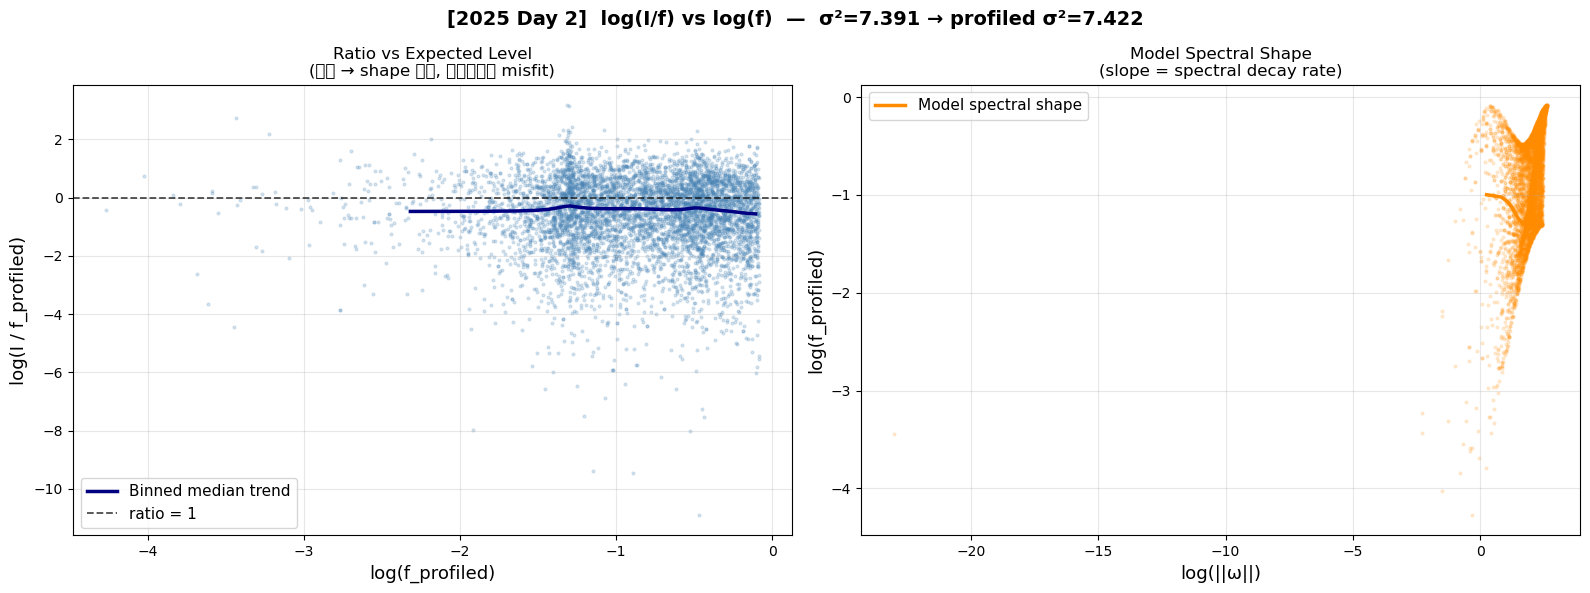

In [7]:
YEAR_PLOT = '2025'
DAY_PLOT  = 2   # 0-based index

plot_logIf_vs_logf(
    day_idx     = DAY_PLOT,
    dw_df       = dw_by_year[YEAR_PLOT],
    raw_tensors = tensors_dw_by_year[YEAR_PLOT],
    raw_maps    = maps_dw_by_year[YEAR_PLOT],
    year_label  = YEAR_PLOT
)

## Run — multiple days

[Day 1] preprocessing...
[Day 1] computing spectral components...
  sigma_input=4.862  sigma_profiled=4.886


/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_2433/1320848817.py:93: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_2433/1320848817.py:93: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_2433/1320848817.py:93: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_2433/1320848817.py:93: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_2433/1320848817.py:93: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykern

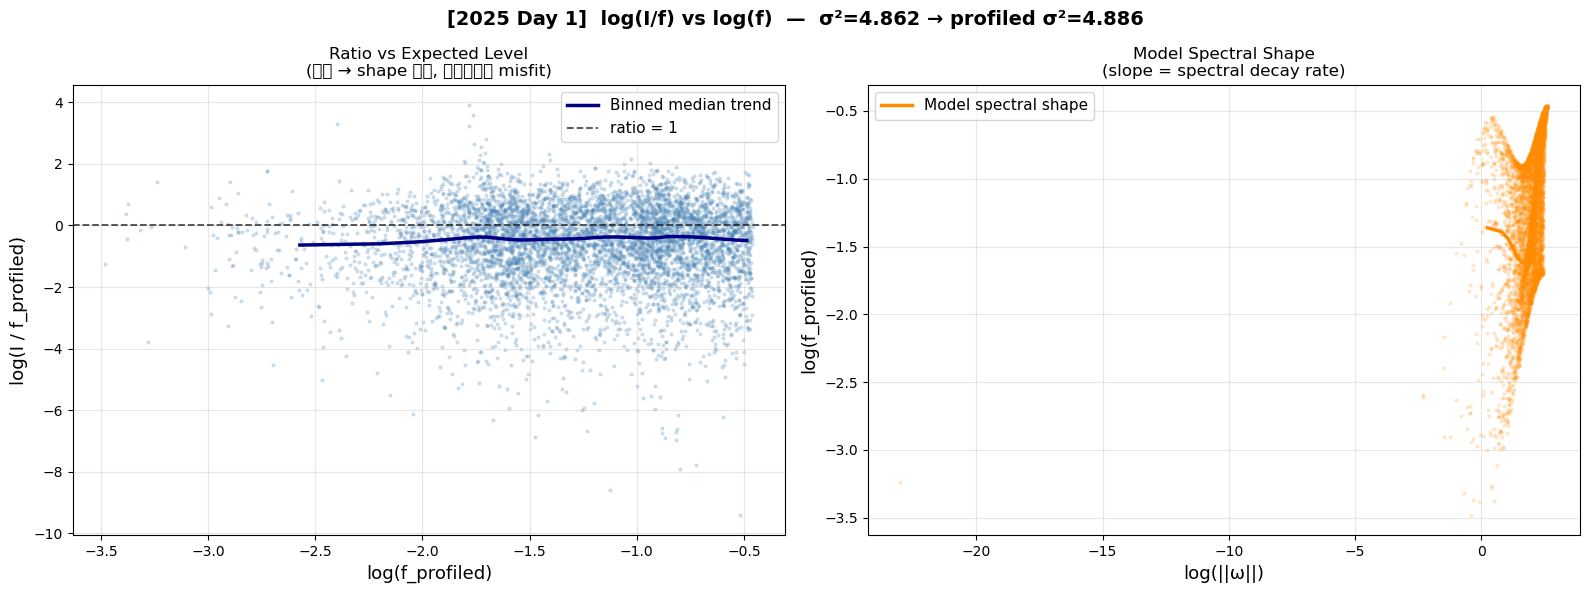

[Day 5] preprocessing...
[Day 5] computing spectral components...
  sigma_input=16.787  sigma_profiled=16.778


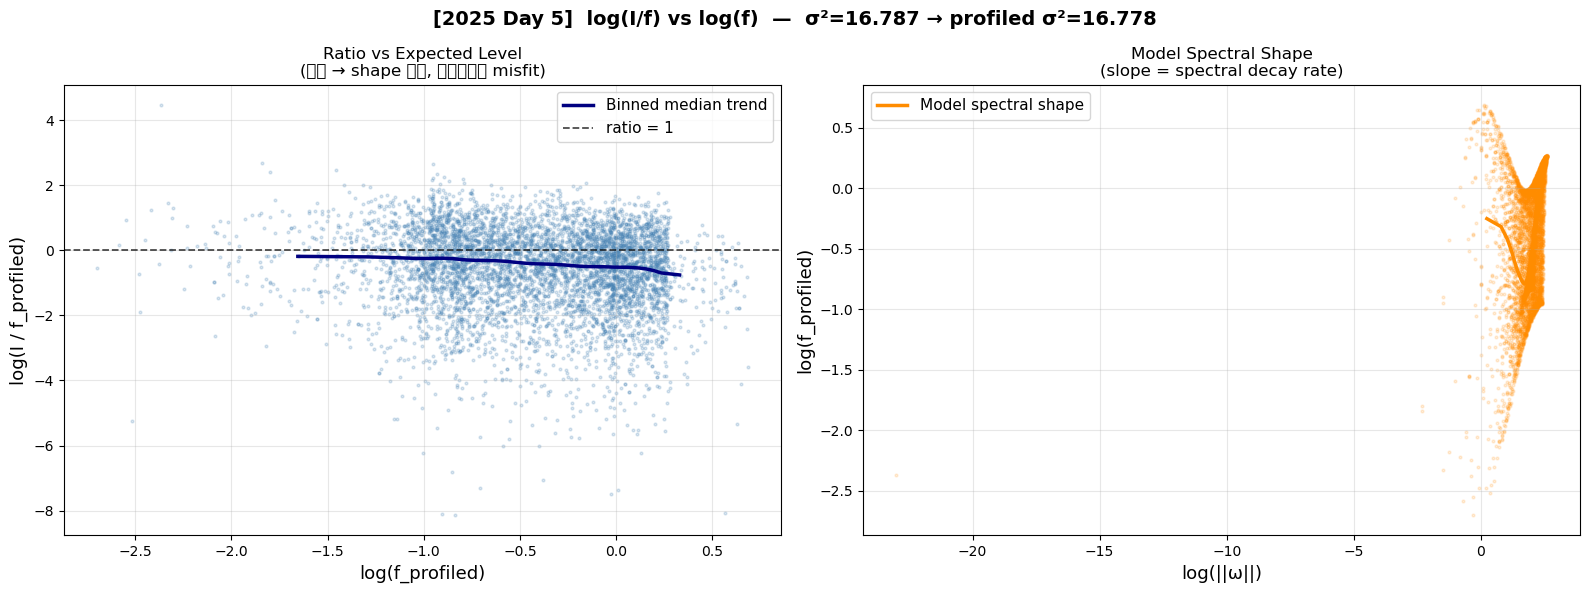

[Day 10] preprocessing...
[Day 10] computing spectral components...
  sigma_input=12.256  sigma_profiled=12.223


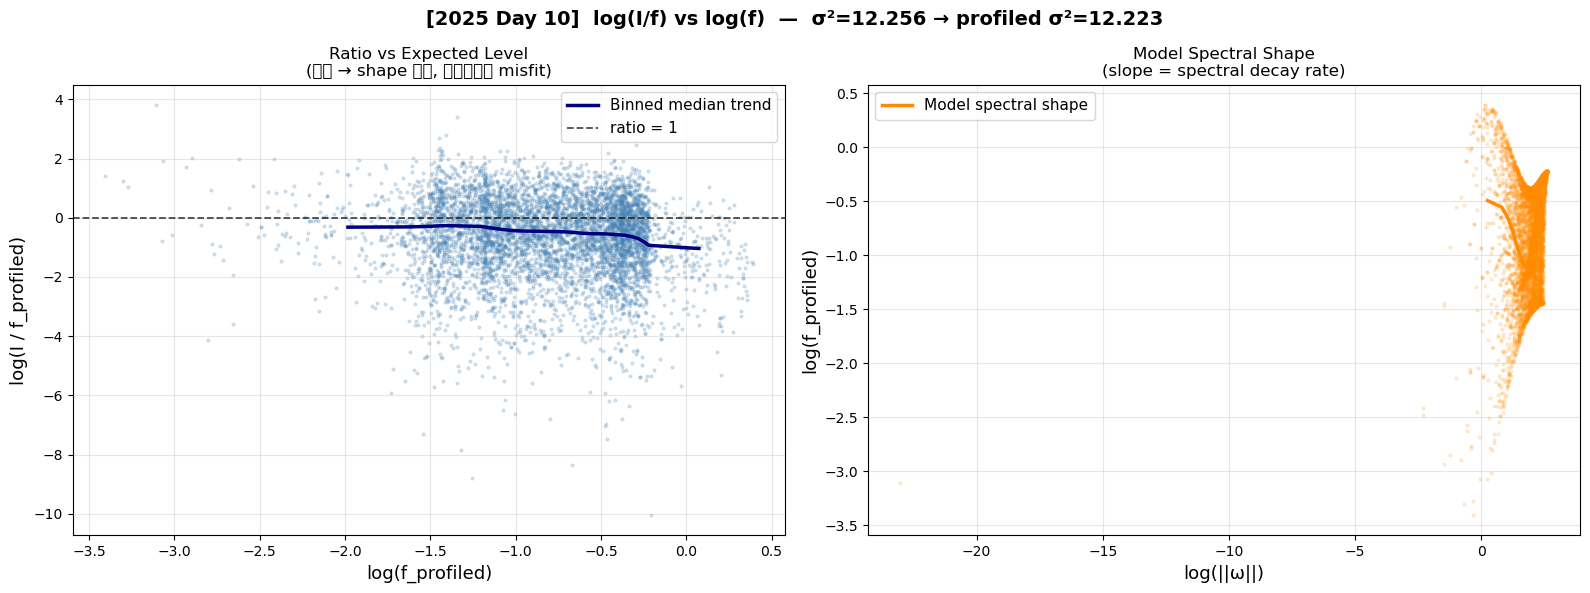

[Day 15] preprocessing...
[Day 15] computing spectral components...
  sigma_input=11.494  sigma_profiled=11.458


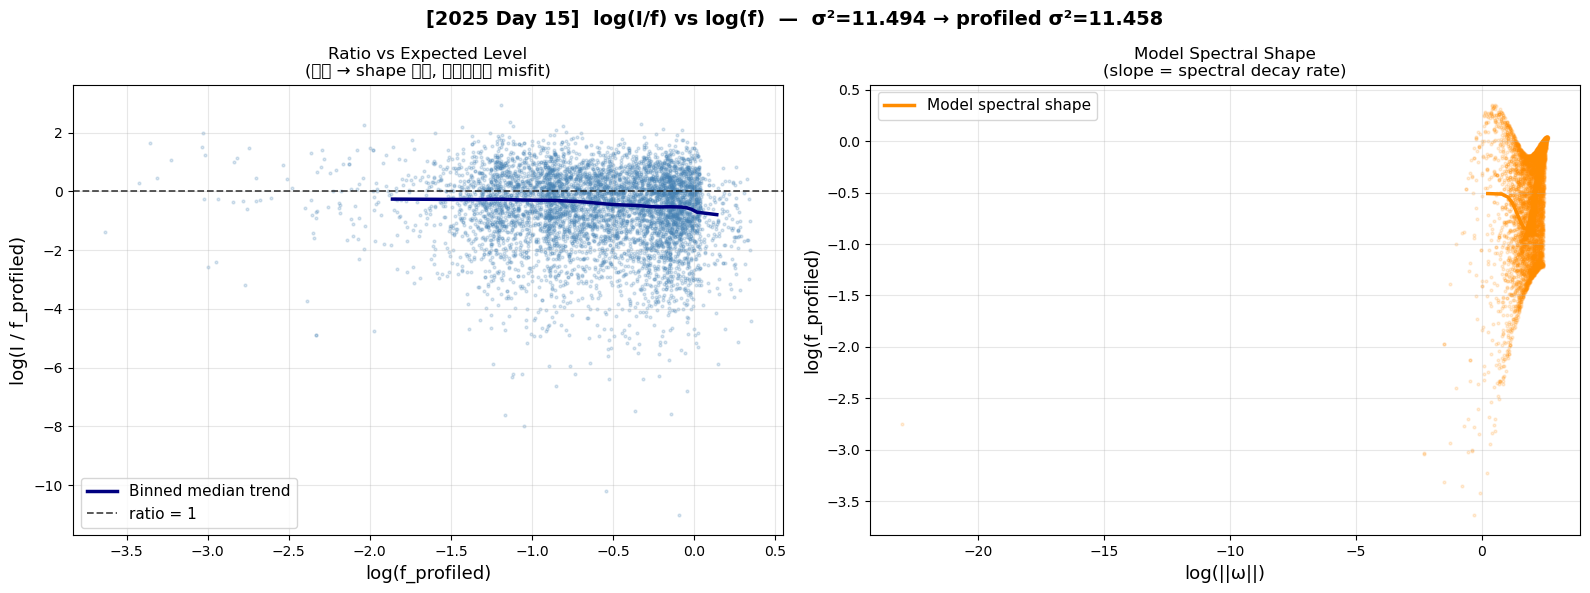

[Day 20] preprocessing...
[Day 20] computing spectral components...
  sigma_input=4.310  sigma_profiled=4.339


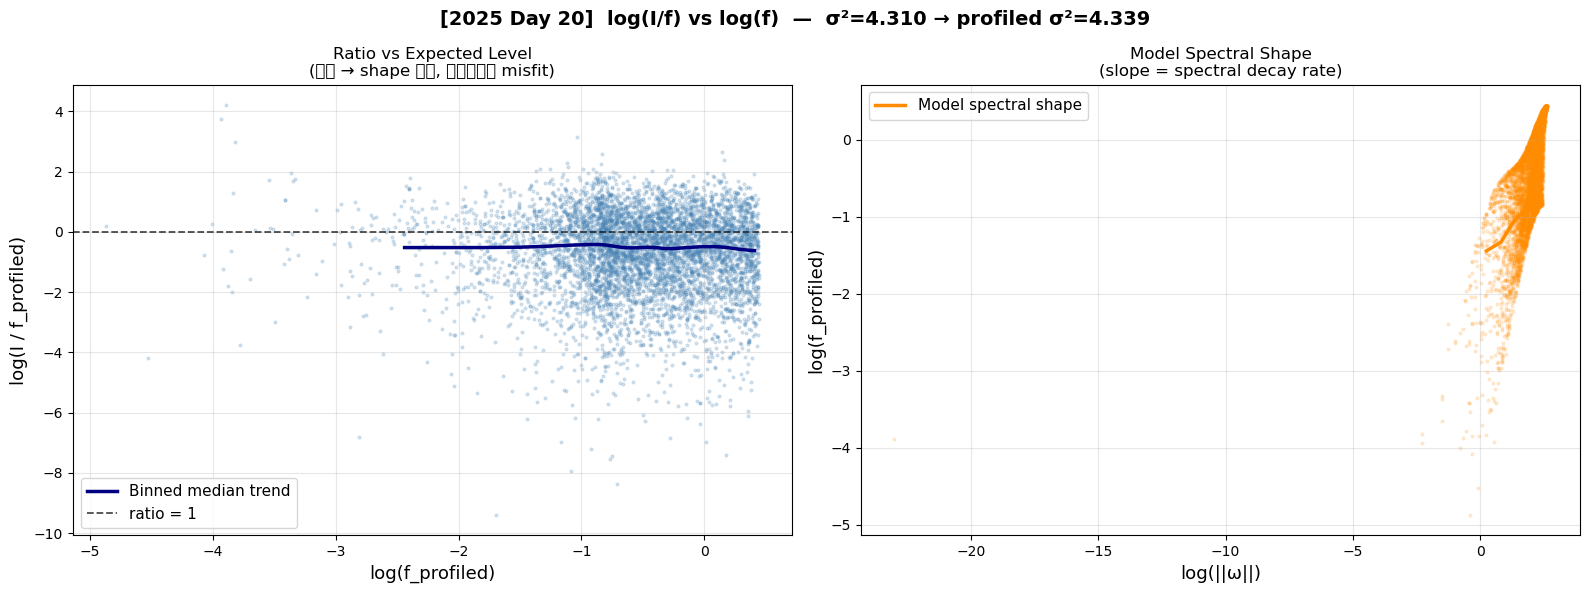

[Day 25] preprocessing...
[Day 25] computing spectral components...
  sigma_input=10.678  sigma_profiled=10.678


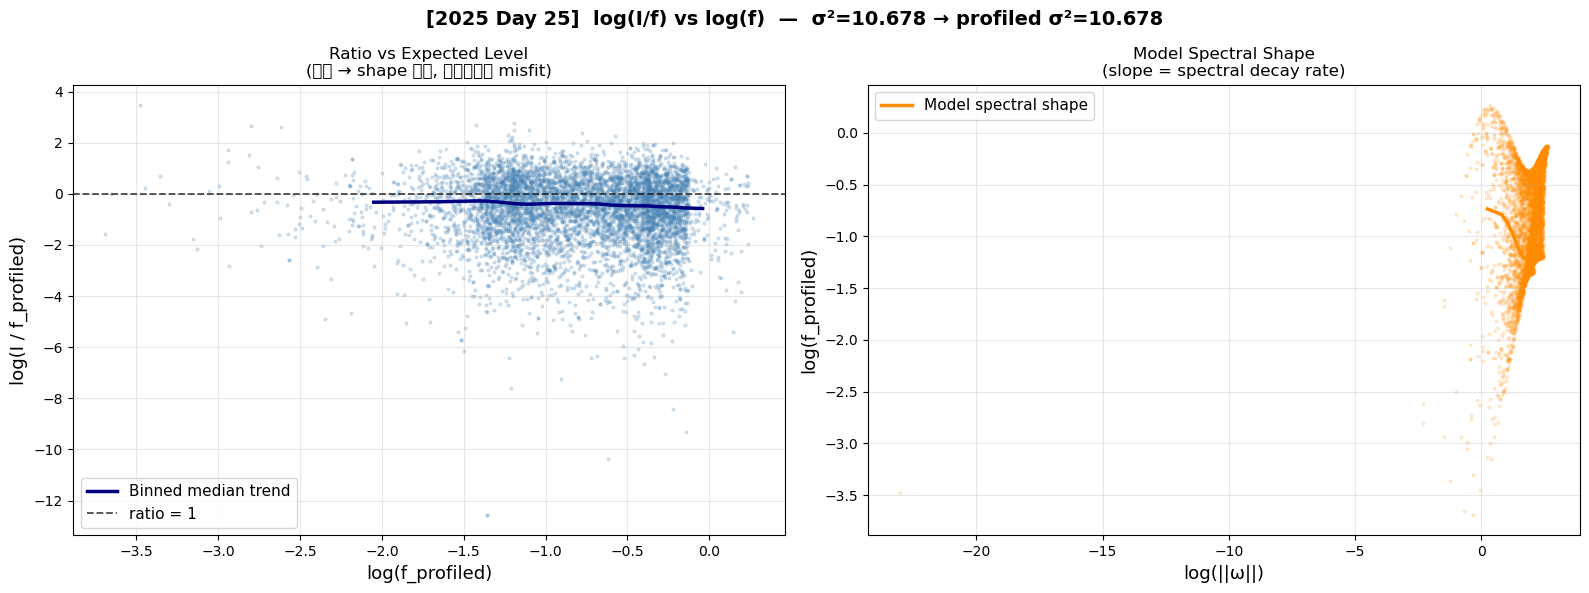

In [8]:
YEAR_PLOT = '2025'
DAYS      = [1, 5, 10, 15, 20, 25]

for d in DAYS:
    plot_logIf_vs_logf(
        day_idx     = d,
        dw_df       = dw_by_year[YEAR_PLOT],
        raw_tensors = tensors_dw_by_year[YEAR_PLOT],
        raw_maps    = maps_dw_by_year[YEAR_PLOT],
        year_label  = YEAR_PLOT
    )